# **Part 1: Data Cleaning & Preparation** 

This notebook prepares five Instacart datasets for rule-based customer segmentation by cleaning, validating, and transforming the data. The goal is to ensure the datasets are consistent, appropriately structured, and suitable for downstream behavioral analysis.

## **Data Sources**
- **customers.csv:** Customer-level demographic information. This dataset has been created for instructional purposes.
- **departments.csv:** Department names and IDs.
- **orders.csv:** Order-level information, including user IDs, order number, day and hour of order, and days since the previous order.
- **products.csv:** Product-level information, including product names, aisle and department IDs, and prices.
- **orders_products_prior.csv:** Product-level information for customers’ historical orders, including products purchased, cart position, and reorder status.

---

## **Notebook Overview**
### **Part 1: Initial Data Exploration**
Reviewing data structure, distributions, and potential data quality issues.

### **Part 2: Data Cleaning & Preparation**
Cleaning, validating, and transforming the datasets for analysis.

#### **Data Wrangling & Cleaning:**
- Dropping irrelevant and personally identifiable information (PII) columns
- Renaming columns for consistency
- Converting columns to appropriate data types
- Identifying and handling missing values
- Identifying and removing duplicate records
- Investigating and addressing extreme values in the `price` column
  
#### **Data Validation (Consistency Checks):**
- Identifying nulls in `days_since_prior_order` column and verifying that they correspond to customers' first orders
- Checking the distribution of the `income` column to identify potential high-income outliers
- Checking the distribution of the `price` column for potential outliers
  
#### **Data Transformation:**
- Mapping numeric values in the `order_dow` column to their corresponding day names
- Creating an `is_first_order` flag based on first-order records identified in the `days_since_prior_order` column
- Reshaping the department dataset from wide to long format to be usable for analysis and future merges

---

## **Part 1: Initial Data Exploration**
- Explored each dataset using **descriptive statistics and summary information** to understand the data structure, distributions, and key variables.
- Documented initial observations and identified **potential data quality issues** to investigate during the cleaning process.

### Importing Libraries & Original Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Creating path to project folder.
path = r'C:\Users\TanaT\Portfolio Projects\Instacart - Customer Segementation & Behavioral Analysis'

# Importing datasets (customers, orders, departments, products, and reordering/cart behavior)
df_cust = pd.read_csv(os.path.join(path, '02 Data', '01 Raw Data', 'customers.csv')) 
df_orders = pd.read_csv(os.path.join(path, '02 Data','01 Raw Data', 'orders.csv'))
df_dept = pd.read_csv(os.path.join(path, '02 Data', '01 Raw Data', 'departments.csv'))
df_prods = pd.read_csv(os.path.join(path, '02 Data', '01 Raw Data', 'products.csv'))
df_orders_products = pd.read_csv(os.path.join(path, '02 Data', '01 Raw Data', 'orders_products_prior.csv'))

### **Customer Data Overview**
- This dataset contains **206, 209 customers**, ranging in age from **18 to 81**.
- It is at the user-level, containing demographic and household information for each unique `user_id`, including `age`, `fam_status`, `income` and other attributes that may provide useful context for customer segmentation. 
- **Although the PII columns in this dataset are synthetic, they will be treated as sensitive information.** 
    - Name data paired with other attributes like `age`, `state`, and `gender` could pose as a privacy risk in a real-world setting. 
    - The `user_id` column will be retained  as a **unique, anonymized** identifier for linking customer records across datasets.

***Data Coverage Note***
- The data spans a four-year period beginning in 2017, based on `date_joined`, several years after Instacart's launch.
- It represents an established and primarily active customer base, with most customers progressing beyond their initial orders. Therefore, this analysis focuses on **behavioral differences among established customers.**

In [3]:
# Customers dataset overview.
df_cust.head()

,user_id,First Name,Surnam,Gender,STATE,Age,date_joined,n_dependants,fam_status,income
0,26711,Deborah,Esquivel,Female,Missouri,48,1/1/2017,3,married,165665
1,33890,Patricia,Hart,Female,New Mexico,36,1/1/2017,0,single,59285
2,65803,Kenneth,Farley,Male,Idaho,35,1/1/2017,2,married,99568
3,125935,Michelle,Hicks,Female,Iowa,40,1/1/2017,0,single,42049
4,130797,Ann,Gilmore,Female,Maryland,26,1/1/2017,1,married,40374


In [4]:
# Checking number of rows and columns in the dataset.
df_cust.shape

(206209, 10)

In [5]:
# Checking data types and possible missing values. 
df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206209 entries, 0 to 206208
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       206209 non-null  int64 
 1   First Name    194950 non-null  object
 2   Surnam        206209 non-null  object
 3   Gender        206209 non-null  object
 4   STATE         206209 non-null  object
 5   Age           206209 non-null  int64 
 6   date_joined   206209 non-null  object
 7   n_dependants  206209 non-null  int64 
 8   fam_status    206209 non-null  object
 9   income        206209 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 15.7+ MB


#### **Data Quality Issues to Address:**
- The only column containing missing values is in the `First Name` column, however this will be dropped for PII reasons. 
- The `user_id` column is stored as an integer, but serves as an identifier. This will be kept as an integer as it is more memory-efficient.
- The`date_joined` column is currently stored as a string and will be converted to datetime format for consistency and appropriate date handling.
- Column names are inconsistent and will be standardized using snake_case, including correcting spelling inconsistencies.

In [6]:
# Checking descriptive statistics.  
df_cust.describe()

,user_id,Age,n_dependants,income
count,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,49.501646,1.499823,94632.852548
std,59527.555167,18.480962,1.118433,42473.786988
min,1.000000,18.000000,0.000000,25903.000000
25%,51553.000000,33.000000,0.000000,59874.000000
50%,103105.000000,49.000000,1.000000,93547.000000
75%,154657.000000,66.000000,3.000000,124244.000000
max,206209.000000,81.000000,3.000000,593901.000000


#### **Initial Observations:**
- While ages range from **18 to 81**, the middle 50% is between **33 and 66 years old**, with an average age of approximately **49.5 years**. 
- Customers have between **0 and 3 dependents**, with no customers having more than three.
- The middle 50% of customer incomes fall between approximately **\\$60K and \\$124K**. The maximum income is substantially higher than the upper quartile, suggesting the presence of higher-income customers that may be potential outliers. These values will be investigated further to determine whether they should be retained or excluded.

---

### **Orders Data Overview**
- This dataset contains over 3 million rows, with one row per unique `order_id`, linked to a unique `user_id`.
- The `order_number` column indicates the sequential order number for each user (1 = first order, 2 = second order, etc.).
- The `order_dow` column codes each day of the week from 0–6, corresponding to Saturday through Friday, respectively.
- Together, these variables, including `days_since_prior_order`, provide insight into customers’ ordering frequency and temporal shopping behavior, which will support the behavioral analysis used for customer segmentation.

In [7]:
# Orders dataset overview
df_orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [8]:
df_orders.shape

(3421083, 7)

In [9]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [10]:
# Checking for missing values. 
df_orders.isnull().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

#### **Data Quality Issues to Address:**
- The `order_id` and `user_id` data types will be kept for reasons previously stated. They will be excluded from mathematical operations where appropriate. 
- The `days_since_prior_order` column contains missing values, which may correspond to customers’ first orders, where no previous order exists. This will be verified during the data cleaning process later in this notebook.
- The `eval_set` column will be dropped, as it is not needed for behavioral analysis or rule-based customer segmentation in this project. 

In [11]:
df_orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


#### **Initial Observations:**
- Orders are distributed throughout the week, with the **middle 50%** of orders placed between approximately **10 AM and 4 PM**, with a **median order time of 1 PM**.
- The distribution of the `order_number` column is right-skewed, with a **median of 11 orders**. Only **25% of orders** occur **beyond the 23rd order**. 
- Customers typically place **subsequent orders within 4–15 days**, with a **median of 7 days**. This may indicate weekly to bi-weekly shopping patterns. However, temporal ordering behavior will be explored in greater depth during later analyses.

---

### **Departments and Products Data Overview**
These datasets add item-level details including `product_name`, `department`, and `price`, which will support the analysis of purchasing patterns and product preferences across departments. These insights will contribute to the behavioral analysis used for rule=based customer segmentation.
- The `product_id` column is a unique identifier for each product.
- The `aisle_id` and `department_id` link each product to its associated category. 

***Limitations:***
- The products dataset contains the product `price`, but does not include a revenue or transaction-value field. f needed, customer or order-level spend can be derived by aggregating product prices across orders or customers.
- The `price` values are fabricated for instructional purposes and should not be interpreted as actual Instacart transaction prices.

#### **Department Dataset**

In [12]:
# Department data overview.
df_dept.head()

,department_id,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,department,frozen,other,bakery,produce,alcohol,international,beverages,pets,dry goods pasta,...,meat seafood,pantry,breakfast,canned goods,dairy eggs,household,babies,snacks,deli,missing


In [13]:
# Checking for missing values. 
df_dept.isnull().sum()

department_id    0
1                0
2                0
3                0
4                0
5                0
6                0
7                0
8                0
9                0
10               0
11               0
12               0
13               0
14               0
15               0
16               0
17               0
18               0
19               0
20               0
21               0
dtype: int64

#### **Data Quality Issues to Address**
- The data is currently in wide format and will be transformed into long format in order to be usable for analysis.
- A new column containing department names will also be created and stored as a categorical variable.
- There are no missing values to address.

#### **Products Dataset**


In [14]:
# Products data overview.
df_prods.head()

,product_id,product_name,aisle_id,department_id,prices
0,1,Chocolate Sandwich Cookies,61,19,5.8
1,2,All-Seasons Salt,104,13,9.3
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5
4,5,Green Chile Anytime Sauce,5,13,4.3


In [15]:
df_prods.shape

(49693, 5)

In [16]:
df_prods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49693 entries, 0 to 49692
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     49693 non-null  int64  
 1   product_name   49677 non-null  object 
 2   aisle_id       49693 non-null  int64  
 3   department_id  49693 non-null  int64  
 4   prices         49693 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.9+ MB


#### **Data Quality Issues to Address:**
- The `product_name` column contains missing values, which will be addressed during the cleaning process. 
- The `department_id` column will be converted to categorical data type for efficiency, as it contains a limited number of departments.
- The `prices` column will be renamed to `price` for accuracy. 

In [17]:
df_prods.describe()

,product_id,aisle_id,department_id,prices
count,49693.000000,49693.000000,49693.000000,49693.000000
mean,24844.345139,67.770249,11.728433,9.994136
std,14343.717401,38.316774,5.850282,453.519686
min,1.000000,1.000000,1.000000,1.000000
25%,12423.000000,35.000000,7.000000,4.100000
50%,24845.000000,69.000000,13.000000,7.100000
75%,37265.000000,100.000000,17.000000,11.200000
max,49688.000000,134.000000,21.000000,99999.000000


#### **Initial Observations:**
- The platform offers **over 49,000 unique products** across **21 departments**.
- The **middle 50%** of items are priced between approximately **\\$4.10 and \\$11.20**, indicating that most products are relatively low-priced.
- The max price of \\$99,999 is an extreme outlier and is likely an error, which will be investigated during data cleaning.

---

### **Prior Orders Product Data Overview**
This dataset contains **product-level** details for customers’ **prior orders**, including which products were purchased, the order in which products were added to the cart, and whether each product had been previously purchased. These variables can support analyses of product preferences, reorder behavior, and cart-level shopping patterns. For this project, the dataset will primarily provide product-level purchasing information that may be incorporated into customer segmentation.
- Each row represents a product within an order, so `order_id` is repeated when an order contains multiple products.
- The `add_to_cart_order` column indicates the sequence in which products were added to the cart within each order.
- The `reordered` column indicates whether the product had been previously added in an order (1 = yes, 0 = no).

In [18]:
# Data overview.
df_orders_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [19]:
df_orders_products.shape

(32434489, 4)

In [20]:
df_orders_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


In [21]:
# Checking for missing values.
df_orders_products.isnull().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

#### **Data Quality Issues to Address:**
- The`reordered` column is currently stored as a integer and will be converted to a boolean (True/False) data type.
- There are no missing values to address. 

In [22]:
# Descriptive statistics.
df_orders_products.describe()

,order_id,product_id,add_to_cart_order,reordered
count,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07
mean,1.710749e+06,2.557634e+04,8.351076e+00,5.896975e-01
std,9.873007e+05,1.409669e+04,7.126671e+00,4.918886e-01
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.559430e+05,1.353000e+04,3.000000e+00,0.000000e+00
50%,1.711048e+06,2.525600e+04,6.000000e+00,1.000000e+00
75%,2.565514e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00


#### **Initial Observations:**
- Without the product names, we cannot identify which specific products are being added to carts or reordered. This will require merging this dataset with the appropriate product-level data.
- The `add_to_cart_order` column has a 75th percentile of 11, indicating that **75% of products** were **added to carts within the first 11 positions**. This suggests that most products are added relatively early in the cart-building process, while the remaining 25% were added later.
- Since `reordered` is a binary variable stored as 0/1, its mean represents the proportion of observations with a value of 1 (reordered). This column has a **mean of 0.589**, indicating that **approximately 59% of products were reordered**.

---

## **Part 2: Data Cleaning & Preparation**
Based on the issues identified during the initial exploration, the following steps clean and transform the data for analysis.

#### Checking all columns in datasets

In [23]:
# Checking columns in customers data. 
df_cust.columns

Index(['user_id', 'First Name', 'Surnam', 'Gender', 'STATE', 'Age',
       'date_joined', 'n_dependants', 'fam_status', 'income'],
      dtype='object')

In [24]:
df_orders.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')

In [25]:
df_prods.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id', 'prices'], dtype='object')

In [26]:
df_orders_products.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')

### **Removing PII and Unused Columns**
Removed personally identifiable information (PII) columns and the `eval_set` column because they are not required for the analysis and removing PII also helps protect customer privacy and limit unnecessary exposure of personal information.

In [27]:
# Dropping PII columns from customer data.
df_cust_clean = df_cust.drop(columns=['First Name', 'Surnam'])

# Dropping 'eval_set' column from orders data. 
df_orders_clean = df_orders.drop(columns=['eval_set'])

In [28]:
# Checking columns again. Dropped two, so shape should have 8 columns.  
df_cust_clean.shape

(206209, 8)

In [29]:
# Columns should now be 6.
df_orders_clean.shape

(3421083, 6)

### **Renaming Columns**
Renamed `gender`, `state`, `age`, `n_dependents`, and `price` columns to follow a consistent naming convention across the dataset.

In [30]:
# Standardizing column names in customers data to snake_case format and correcting spelling of 'dependants' to 'dependents'. 
df_cust_clean.rename(columns={'Gender':'gender', 'STATE':'state', 'Age':'age', 'n_dependants':'n_dependents',}, inplace=True)

In [31]:
# Checking change. 
df_cust_clean.columns

Index(['user_id', 'gender', 'state', 'age', 'date_joined', 'n_dependents',
       'fam_status', 'income'],
      dtype='object')

In [32]:
# Renaming 'prices' column. 
df_prods.rename(columns={'prices':'price'}, inplace=True)

In [33]:
# Checking columns.
df_prods.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id', 'price'], dtype='object')

### **Converting Data Types**
- Converted `date_joined` from an `object` to datetime format to ensure the column uses the appropriate data type for dates.
- Converted `reordered` from `int64` to boolean because the variable represents a binary indicator of whether a product was reordered.

In [34]:
# Checking the format of dates before converting datatype. 
df_cust_clean['date_joined'].sample(5)

171476    9/15/2019
150527    5/17/2019
98512     7/21/2018
160013    7/11/2019
97925     7/18/2018
Name: date_joined, dtype: object

In [35]:
# Converting 'date_joined' column from object in customer dataset to datetime using MM/DD/YYYY format.
df_cust_clean['date_joined'] = pd.to_datetime(df_cust['date_joined'], format='%m/%d/%Y')

In [36]:
# Checking if format was implemented correctly. 
df_cust_clean.dtypes

user_id                  int64
gender                  object
state                   object
age                      int64
date_joined     datetime64[ns]
n_dependents             int64
fam_status              object
income                   int64
dtype: object

In [37]:
# Checking if all dates were converted. If not, there could be nulls. 
df_cust_clean['date_joined'].isnull().sum()

np.int64(0)

In [38]:
# Converting 'reordered' column to boolean. 
df_orders_products['reordered'] = df_orders_products['reordered'].astype(bool)

In [39]:
# Checking datatype. 
df_orders_products.dtypes

order_id             int64
product_id           int64
add_to_cart_order    int64
reordered             bool
dtype: object

### **Converting Columns to Categorical Data Types**
- Columns containing a limited number of repeated values were converted to the categorical data type to improve memory efficiency and support more efficient data processing.
- The following columns were converted: `gender`, `state`, `fam_status`, `order_dow`, and `department`.

In [40]:
# Customer categorical variables. 
df_cust_clean = df_cust_clean.astype({
    'gender': 'category',
    'state': 'category',
    'fam_status': 'category'
})

In [41]:
# Checking datadypes.
df_cust_clean.dtypes

user_id                  int64
gender                category
state                 category
age                      int64
date_joined     datetime64[ns]
n_dependents             int64
fam_status            category
income                   int64
dtype: object

### **Mapping Days of the Week**
- The `order_dow` column contains numeric values 0–6. These will be mapped to their corresponding day-of-week names to improve interpretability during analysis and visualization.
- This variable is then converted to a **categorical data type** for consistency.

In [42]:
# Checking values in 'order_dow' column before making changes.
df_orders_clean['order_dow'].unique()

array([2, 3, 4, 1, 5, 0, 6])

In [43]:
# Mapping days of the week with names.  
dow_names = {
    0: 'Saturday',
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday'
}

# Putting the days in order and making the data type categorical. 
dow_order = [
    'Saturday', 'Sunday', 'Monday', 'Tuesday',
    'Wednesday', 'Thursday', 'Friday'
]

# Categories have a logical order.
from pandas.api.types import CategoricalDtype
ordered_cat = CategoricalDtype(categories=dow_order, ordered=True)


# Mapping the names and converting column to categorical. 
df_orders_clean['order_dow'] = df_orders_clean['order_dow'].map(dow_names).astype(ordered_cat)

In [44]:
# Checking datatypes after changes.
df_orders_clean.dtypes

order_id                     int64
user_id                      int64
order_number                 int64
order_dow                 category
order_hour_of_day            int64
days_since_prior_order     float64
dtype: object

In [45]:
# Checking column values. 
df_orders_clean['order_dow'].unique()

['Monday', 'Tuesday', 'Wednesday', 'Sunday', 'Thursday', 'Saturday', 'Friday']
Categories (7, object): ['Saturday' < 'Sunday' < 'Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday']

### **Reshaping Departments Data**
- The department data is provided in a **wide format**, with department IDs and names stored across columns. It will be reshaped into a **long format** so that each department is represented as a single row with its corresponding `department_id` and department name.
- This structure will make the table easier to join with product-level data and use in subsequent analysis.

In [46]:
# Original format. 
df_dept.head()

,department_id,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,department,frozen,other,bakery,produce,alcohol,international,beverages,pets,dry goods pasta,...,meat seafood,pantry,breakfast,canned goods,dairy eggs,household,babies,snacks,deli,missing


In [47]:
# Converting to long format. 
df_long = df_dept.melt(          
    var_name='department_id',    
    value_name='0'
)

print(df_long)

    department_id                0
0   department_id       department
1               1           frozen
2               2            other
3               3           bakery
4               4          produce
5               5          alcohol
6               6    international
7               7        beverages
8               8             pets
9               9  dry goods pasta
10             10             bulk
11             11    personal care
12             12     meat seafood
13             13           pantry
14             14        breakfast
15             15     canned goods
16             16       dairy eggs
17             17        household
18             18           babies
19             19           snacks
20             20             deli
21             21          missing


In [48]:
# Keeping everything but the first row and resetting the index. 
df_dept_clean = df_long[1:].reset_index(drop=True)
print(df_dept_clean)

   department_id                0
0              1           frozen
1              2            other
2              3           bakery
3              4          produce
4              5          alcohol
5              6    international
6              7        beverages
7              8             pets
8              9  dry goods pasta
9             10             bulk
10            11    personal care
11            12     meat seafood
12            13           pantry
13            14        breakfast
14            15     canned goods
15            16       dairy eggs
16            17        household
17            18           babies
18            19           snacks
19            20             deli
20            21          missing


In [49]:
# Renaming column '0' to be 'department'.
df_dept_clean = df_dept_clean.copy() # Avoid warning
df_dept_clean.rename(columns={'0':'department'}, inplace=True)

In [50]:
# Checking to be sure there are two columns.
df_dept_clean.columns

Index(['department_id', 'department'], dtype='object')

In [51]:
# Overview of reshaped data.
df_dept_clean.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


#### **Cleaning Result**
The department data was reshaped into a tabular format with one row per department, allowing it to be joined to the product dataset using department_id.

In [52]:
# Final shape.
df_dept_clean.shape

(21, 2)

In [53]:
# Checking datatypes.
df_dept_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     object
 1   department     21 non-null     object
dtypes: object(2)
memory usage: 468.0+ bytes


#### Converting the `department_id` column to an integer for consistency and `department` column to be categorical for memory efficiency.

In [54]:
# Converting 'department_id' column to integer.
df_dept_clean['department_id'] = df_dept_clean['department_id'].astype(int)

# Converting 'department' column to category.
df_dept_clean['department'] = df_dept_clean['department'].astype('category')

In [55]:
# Checking final datatypes.
df_dept_clean.dtypes

department_id       int64
department       category
dtype: object

### **Identifying & Handling Missing Values**
- Identified that all null values in the `days_since_prior_order` column correspond to **first-time orders**.
- Created a flag column for first orders (`is_first_order`).
- Null values in `product_name` column dropped.

#### Checking Nulls in Orders Data

In [56]:
# Checking nulls in orders data.
df_orders_clean.isnull().sum()

order_id                       0
user_id                        0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [57]:
# Making a dataframe only containing nulls. 
df_ords_nulls = df_orders_clean[df_orders_clean.isnull().any(axis=1)]
df_ords_nulls

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,Monday,8,NaN
11,2168274,2,1,Monday,11,NaN
26,1374495,3,1,Sunday,14,NaN
39,3343014,4,1,Friday,11,NaN
45,2717275,5,1,Tuesday,12,NaN
...,...,...,...,...,...,...
3420930,969311,206205,1,Wednesday,12,NaN
3420934,3189322,206206,1,Tuesday,18,NaN
3421002,2166133,206207,1,Friday,19,NaN
3421019,2227043,206208,1,Sunday,15,NaN


In [58]:
# Checking the order number of the nulls.
df_ords_nulls['order_number'].value_counts()

order_number
1    206209
Name: count, dtype: int64

In [59]:
# Checking logic if all nulls correspond to first orders.
(df_ords_nulls['days_since_prior_order'].isnull() == (df_ords_nulls['order_number'] == 1)).all()

np.True_

#### **Data Verification**
- This verifies that all nulls in the `days_since_prior_order` column correspond to first orders.
- All nulls in the column correspond to `order number = 1`, indicating that these values represent the absence of a previous order rather than missing or erroneous data.

#### Flagging First Orders
These nulls are structurally meaningful, so rather than imputing or removing them, first orders will be explicitly flagged to distinguish them from subsequent orders.

In [60]:
# Creating a column in orders data to flag first orders. 
df_orders_clean['is_first_order'] = df_orders_clean['days_since_prior_order'].isnull()

In [61]:
# Checking orders data again. 
df_orders_clean.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2539329,1,1,Monday,8,NaN,True
1,2398795,1,2,Tuesday,7,15.0,False
2,473747,1,3,Tuesday,12,21.0,False
3,2254736,1,4,Wednesday,7,29.0,False
4,431534,1,5,Wednesday,15,28.0,False


#### Checking Nulls in Products Data

In [62]:
# Checking nulls in products data.
df_prods.isnull().sum()

product_id        0
product_name     16
aisle_id          0
department_id     0
price             0
dtype: int64

In [63]:
# Percent of missing data. 
df_prods.isnull().sum() * 100/len(df_prods)

product_id       0.000000
product_name     0.032198
aisle_id         0.000000
department_id    0.000000
price            0.000000
dtype: float64

#### Products data contains 16 nulls, which is approximately 0.03% of the entire `product_name` column.

In [64]:
# Creating a dataframe to see only nulls. 
df_prods_nulls = df_prods[df_prods.isnull().any(axis=1)]
df_prods_nulls

,product_id,product_name,aisle_id,department_id,price
33,34,NaN,121,14,12.2
68,69,NaN,26,7,11.8
115,116,NaN,93,3,10.8
261,262,NaN,110,13,12.1
525,525,NaN,109,11,1.2
1511,1511,NaN,84,16,14.3
1780,1780,NaN,126,11,12.3
2240,2240,NaN,52,1,14.2
2586,2586,NaN,104,13,12.4
3159,3159,NaN,126,11,13.1


In [65]:
# Seeing which departments contain the most nulls.
df_prods_nulls['department_id'].value_counts()

department_id
16    4
11    3
13    2
7     2
14    1
3     1
1     1
8     1
12    1
Name: count, dtype: int64

#### **Handling Missing Product Names & Resolution**
- This dataset contains **16 null values** all in the `product_name` column.
- In a real-world setting, these records could be investigated and validated against the source data. However, the available data does not provide enough information to reliably identify these products.
- As a result, these records will be **excluded from the analysis**, affecting approximately **0.03% of product records** and resulting in minimal data loss.

In [66]:
# Dropping the 16 nulls in the 'product_name' column. 
df_prods_clean = df_prods.dropna(subset=['product_name']) 

In [67]:
# Final shape.
df_prods_clean.shape

(49677, 5)

### **Identifying & Removing Duplicates**
- Identified duplicate `product_id` records in the products dataset.
-  After reviewing the duplicates, the first occurrence of each `product_id` was retained to preserve one product record per ID.

In [68]:
# Checking customers data for duplicate rows.
df_cust_clean.duplicated().sum()

np.int64(0)

In [69]:
# Checking if all user ids are unique.
df_cust_clean[df_cust_clean.duplicated(subset=['user_id'], keep=False)]

,user_id,gender,state,age,date_joined,n_dependents,fam_status,income


#### All user IDs are unique. No duplicates found in customers data.

In [70]:
# Checking orders data for duplicate rows. 
df_orders_clean.duplicated().sum()

np.int64(0)

In [72]:
# Checking if all order ids are unique.
df_orders_clean['order_id'].duplicated().sum()

np.int64(0)

In [73]:
# Checking if combination of order and user ids are unique. 
df_orders[df_orders.duplicated(subset=['order_id', 'user_id'], keep=False)]

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order


#### No duplicates in orders data. 

In [74]:
# Checking for duplicate rows in departments data. 
df_dept_clean.duplicated().sum()

np.int64(0)

In [75]:
# Checking that all dept. ids are unique.
df_dept_clean['department_id'].duplicated().sum()

np.int64(0)

#### No duplicates found in the departments data. 

In [76]:
# Checking for duplicate rows. 
df_prods_clean.duplicated().sum()

np.int64(5)

In [77]:
# Checking for duplicates in 'product_id' column specifically. 
df_prods['product_id'].duplicated().sum()

np.int64(7)

#### Dropping `product_id` duplicates in products dataset.

In [78]:
# Checking for true duplicates (rows duplicated across all columns) including the first instance. 
df_prods_clean[df_prods_clean.duplicated(keep=False)]

,product_id,product_name,aisle_id,department_id,price
461,462,Fiber 4g Gummy Dietary Supplement,70,11,4.8
462,462,Fiber 4g Gummy Dietary Supplement,70,11,4.8
18458,18458,Ranger IPA,27,5,9.2
18459,18458,Ranger IPA,27,5,9.2
26809,26808,Black House Coffee Roasty Stout Beer,27,5,13.4
26810,26808,Black House Coffee Roasty Stout Beer,27,5,13.4
35308,35306,Gluten Free Organic Peanut Butter & Chocolate ...,121,14,6.8
35309,35306,Gluten Free Organic Peanut Butter & Chocolate ...,121,14,6.8
35494,35491,Adore Forever Body Wash,127,11,9.9
35495,35491,Adore Forever Body Wash,127,11,9.9


In [79]:
# Checking for duplicates in 'product_id' column specifically.
df_prods_clean[df_prods_clean.duplicated(subset='product_id', keep=False)]

,product_id,product_name,aisle_id,department_id,price
461,462,Fiber 4g Gummy Dietary Supplement,70,11,4.8
462,462,Fiber 4g Gummy Dietary Supplement,70,11,4.8
6799,6800,Revive Zero Vitamin Water,64,7,6.4
6800,6800,Sprouted Quinoa Flakes Baby Cereal,92,18,14.0
18458,18458,Ranger IPA,27,5,9.2
18459,18458,Ranger IPA,27,5,9.2
26520,26520,Clinical Advanced Solid Ultimate Fresh Anti-Pe...,80,11,10.6
26521,26520,Cheese Shredded Sharp Cheddar Reduced Fat 2%,21,16,2.9
26809,26808,Black House Coffee Roasty Stout Beer,27,5,13.4
26810,26808,Black House Coffee Roasty Stout Beer,27,5,13.4


#### **Duplicate Data & Resolution**
- Most of the duplicates are **true duplicates** (complete rows are duplicated).
- However, there are a few **naming inconsistencies** as well, where the same `product_id` (6800 and 26520) has different product names.
- To resolve these issues, all `product_id` duplicates will be dropped and the **first occurrence will be kept** to preserve as much data as possible.

In [80]:
# Keeping only the first occurrence of product_id. 
df_prods_clean = (df_prods_clean.sort_index().drop_duplicates(subset='product_id', keep='first'))

In [81]:
# Checking the first occurrence that was kept. 
df_prods_clean[df_prods_clean['product_id'].isin([6800, 26520])]

,product_id,product_name,aisle_id,department_id,price
6799,6800,Revive Zero Vitamin Water,64,7,6.4
26520,26520,Clinical Advanced Solid Ultimate Fresh Anti-Pe...,80,11,10.6


In [82]:
# Final shape. 
df_prods_clean.shape

(49670, 5)

In [83]:
# Should have 49670 unique product ids.
df_prods_clean['product_id'].nunique()

49670

In [84]:
# Final check of duplicates for products data. 
df_prods_clean[df_prods_clean.duplicated(subset='product_id', keep=False)]

,product_id,product_name,aisle_id,department_id,price


#### **Cleaning Result**
No duplicate `product_id` records remain in the products dataset, ensuring one unique product record per ID.

In [85]:
# Checking for duplicate rows in cart behavior data.
df_orders_products.duplicated().sum()

np.int64(0)

In [86]:
# Repeated order_ids are expected since an order can contain multiple products.
# However, each product should appear only once per order.
# Checking if the same product was added twice during the same order.
df_orders_products[df_orders_products.duplicated(subset=['order_id', 'product_id'], keep=False)]

,order_id,product_id,add_to_cart_order,reordered


In [87]:
# The 'add_to_cart_order' should be a unique sequence for each 'order_id'. 
df_orders_products[df_orders_products.duplicated(subset=['order_id', 'add_to_cart_order'], keep=False)]

,order_id,product_id,add_to_cart_order,reordered


No duplicates found in the `df_orders_products` dataset.

### **Identifying and Addressing Outliers**
- Retaining the high-income earners, since they are within a plausible range and may accurately represent customer incomes
- Dropping the outliers in the `price` column in products data

#### Income Spread 

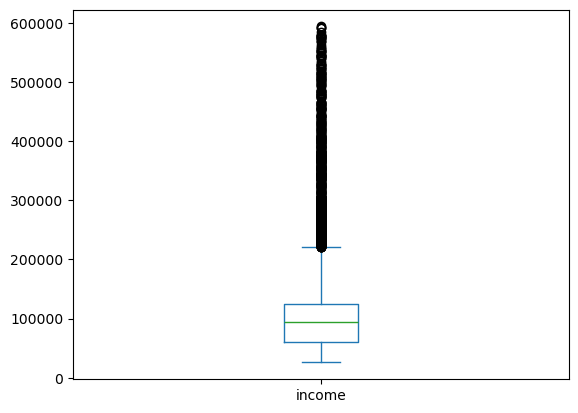

In [88]:
# Checking the distribution of customer incomes with a boxplot.
df_cust_clean['income'].plot(kind='box')
plt.show()

In [89]:
# Calculating the upper/lower bounds and the IQR to see what income would be considered an outlier. 
Q1 = df_cust_clean['income'].quantile(0.25)
Q3 = df_cust_clean['income'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print(f" upper bound: {upper_bound}")

 upper bound: 220799.0


In [90]:
# Counting how many values exceed the upper bound. 
(df_cust_clean['income'] > upper_bound).sum()

np.int64(875)

In [91]:
# Calculating the percentage of the outliers (above the upper bound of ~$220k)
(df_cust_clean['income'] > upper_bound).mean()

np.float64(0.0042432677526199145)

#### **Data Finding & Approach:**
- Although the box plot identifies **875 potential outliers** above the upper bound of approximately \\**$220,000**, these values represent only **0.42%** of the income data.
- Given their small proportion and the fact that these income levels remain within a plausible range, the values will be retained to preserve potentially valid customer information and avoid unnecessarily removing data.

#### Price Spread

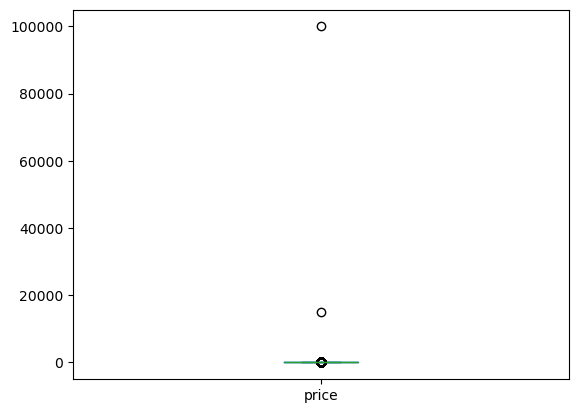

In [92]:
# Checking distribution of prices. 
df_prods_clean['price'].plot(kind='box')
plt.show()

#### **Data Finding & Approach**
- The box plot shows that product prices are **highly right-skewed**, with the majority of products concentrated at relatively low price points.
- Two extreme outliers appear in the distribution, with prices exceeding **\\$20,000** and **\\$100,000** respectively.
- These are likely data quality issues and since they are inconsistent with the expected price range for grocery products, they will be **excluded from the analysis** to prevent them from disproportionately affecting price-based metrics.

In [93]:
# Showing the top 10 highest prices to see what is usual/unusual.
df_prods_clean.nlargest(10, 'price')

,product_id,product_name,aisle_id,department_id,price
33666,33664,2 % Reduced Fat Milk,84,16,99999.0
21554,21553,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0
9020,9020,Boneless Skinless Chicken Thighs,35,12,25.0
19392,19391,Turkey Breast Tenderloins,49,12,25.0
21468,21467,Wild Caught Raw Shrimp,15,12,25.0
25580,25579,Naturally Smoked Trout Fillet,15,12,25.0
40490,40486,Chicken Tenders,49,12,25.0
9896,9896,Uncured Applewood Smoked Bacon,106,12,24.9
14207,14207,Angus Roast Beef,7,12,24.9
36577,36573,Peppered Bacon,106,12,24.9


#### **Data Check & Resolution**
- The two extreme outliers are clearly inconsistent with the expected product price range, as the vast majority of products are priced at **$25 or less**.
- In real-world settings, these values would be validated against the source data before removal. For this project, they will be **filtered out** from the analysis to reduce their potential distortion of price-based metrics.

#### Filtering Out Extreme Outliers in `price` Column

In [94]:
# Filtering out the outliers with a buffer. 
df_prods_clean = df_prods_clean[df_prods_clean['price'] < 50]

<Axes: >

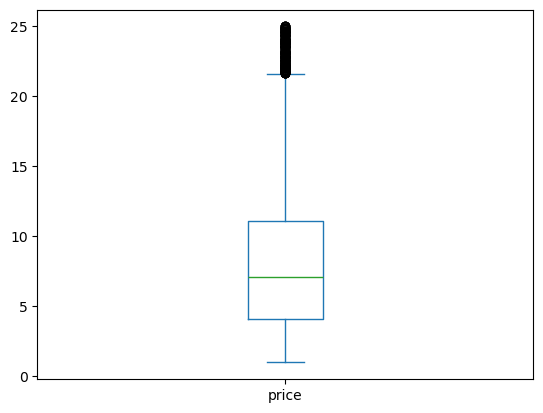

In [95]:
# Replotting to check distribution of prices after removing outliers. 
df_prods_clean['price'].plot(kind='box')

#### **Cleaning Result**
After removing the two extreme outliers, the box plot better reflects the underlying product price distribution. Most products are low-cost, with a smaller number of moderately priced items above $20, primarily from the Meat & Seafood department (`department_id = 12`).

---

## **Exporting Cleaned Datasets**
The cleaned datasets are exported as pickle files (`.pkl`) to preserve their pandas data structures, data types, and other metadata. These files can then be loaded directly into subsequent analysis notebooks without repeating the cleaning and preparation steps.

In [96]:
# Exporting datasets as a CSV file for readability and as a pickle (preserves datatypes) for workflow. 

# CSV files
df_cust_clean.to_csv(os.path.join(path,'02 Data', '02 Processed Data', 'customers_cleaned.csv'))
df_orders_clean.to_csv(os.path.join(path, '02 Data', '02 Processed Data', 'orders_cleaned.csv'))
df_dept_clean.to_csv(os.path.join(path, '02 Data', '02 Processed Data', 'reshaped_dept_clean.csv'))
df_prods_clean.to_csv(os.path.join(path, '02 Data', '02 Processed Data', 'products_cleaned.csv')) 
df_orders_products.to_csv(os.path.join(path, '02 Data', '02 Processed Data', 'cart_behavior_cleaned.csv')) 

In [97]:
# Pickles
df_cust_clean.to_pickle(os.path.join(path, '02 Data', '02 Processed Data', 'customers_cleaned.pkl'))
df_orders_clean.to_pickle(os.path.join(path, '02 Data', '02 Processed Data', 'orders_cleaned.pkl'))
df_dept_clean.to_pickle(os.path.join(path, '02 Data', '02 Processed Data', 'reshaped_dept_clean.pkl'))
df_prods_clean.to_pickle(os.path.join(path, '02 Data', '02 Processed Data', 'products_cleaned.pkl'))
df_orders_products.to_pickle(os.path.join(path, '02 Data', '02 Processed Data', 'cart_behavior_cleaned.pkl'))